# Simple Linear Regression



## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from myst_nb import glue
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

import pingouin as pg

## Load data, get variables

The purity of oxygen (Y, %)produced by a fractional distillation process is thought to be related to the percentage of hydrocarbons (X, %) in the main condensor of the  processing unit. Twenty samples are observed. 

In [3]:
def load_data(data):
    dataset = pd.read_csv(data)
    return dataset

data = 'd://z/data_analysis/linear_regression/linreg_data.csv'
dataset = load_data(data)

xData = dataset['x']
yData = np.array(dataset['y'])


### Data 2

In [3]:
trees = sm.datasets.get_rdataset('trees').data


## Scatter Plot of Data

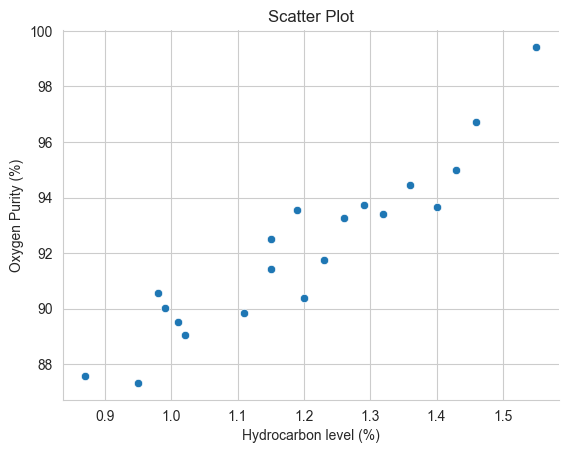

In [4]:

fig = plt.figure()
ax = sns.scatterplot(x=xData, y=yData)
ax.set(title = 'Scatter Plot', ylabel = 'Oxygen Purity (%)', xlabel='Hydrocarbon level (%)')
sns.despine()
plt.show()
glue("sleepycorrelation-fig", fig, display=False)


## Find Coefficients

In [5]:
# Calculate the mean of input (x) and output (y) data
x_mean = np.mean(xData)
y_mean = np.mean(yData)

# Calculate the terms of needed for slope (b1) and intercept (b2) of the regression line
numerator = np.sum((xData - x_mean) * (yData - y_mean))
denomerator = np.sum((xData - x_mean) ** 2)

# Calculate the slope (b1) and intercept (b2) of the regression line (regression equation)
slope_ = numerator / denomerator
intercept_ = y_mean - slope_ * x_mean

print(f"Simple linear equation: y = {intercept_:.3f} + {slope_:.3f}x")
print(f"Slope: {slope_:.3f}")
print(f"Intercept: {intercept_:.3f}")

Simple linear equation: y = 74.283 + 14.947x
Slope: 14.947
Intercept: 74.283


## Make Prediction

In [6]:
# Prediciton
y_pred = intercept_ + slope_ * xData

## Plot Residual

       x      y
0   0.99  90.01
1   1.02  89.05
2   1.15  91.43
3   1.29  93.74
4   1.46  96.73
5   1.36  94.45
6   0.87  87.59
7   1.23  91.77
8   1.55  99.42
9   1.40  93.65
10  1.19  93.54
11  1.15  92.52
12  0.98  90.56
13  1.01  89.54
14  1.11  89.85
15  1.20  90.39
16  1.26  93.25
17  1.32  93.41
18  1.43  94.98
19  0.95  87.33


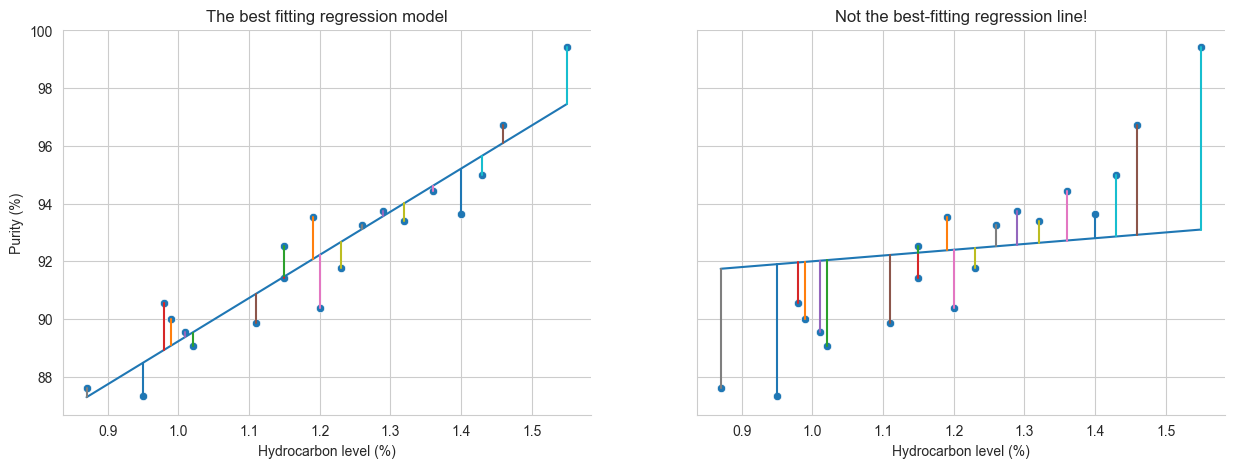

In [8]:
from scipy.optimize import curve_fit

# Fit linear regression model and save parameters
def func(x, a, b):
    return a * x + b

intialParameters = np.array([1.0, 1.0])

fittedParameters, pcov = curve_fit(func, xData, yData, intialParameters)

modelPredictions = func(xData, *fittedParameters)

data = pd.DataFrame({'x': xData, 'y': yData})
print(data)

# plot data points
fig, ax = plt.subplots(1, 2, figsize=(15,5), sharey=True)
sns.scatterplot(data= data, x='x', y='y', ax=ax[0])
ax[0].set_title('The best fitting regression model')
ax[0].set_xlabel('Hydrocarbon level (%)')
ax[0].set_ylabel('Purity (%)')

# add regression line
xModel = np.linspace(min(xData), max(xData))
yModel = func(xModel, *fittedParameters)
ax[0].plot(xModel, yModel)

# add drop lines
for i in range(len(xData)):
    lineXdata = (xData[i], xData[i])
    lineYdata = (yData[i], modelPredictions[i])
    ax[0].plot(lineXdata, lineYdata)

"""Poor-Fitting Model"""
badParameters = np.array([2,90])
badPredictions = func(xData, *badParameters)

bad_xModel = np.linspace(min(xData), max(xData))
bad_yModel = func(bad_xModel, *badParameters)

# Plot data
sns.scatterplot(data= data, x='x', y='y', ax=ax[1])
ax[1].set_title("Not the best-fitting regression line!")
ax[1].set_xlabel("Hydrocarbon level (%)")
ax[1].set_ylabel("Purity (%)")
ax[1].plot(bad_xModel, bad_yModel)

# add drop lines
for i in range(len(xData)):
    lineXdata = (xData[i], xData[i])
    lineYdata = (yData[i], badPredictions[i])
    ax[1].plot(lineXdata, lineYdata)

sns.despine()

plt.show()
glue("regression-fig", fig, display=False)

## Regression plot

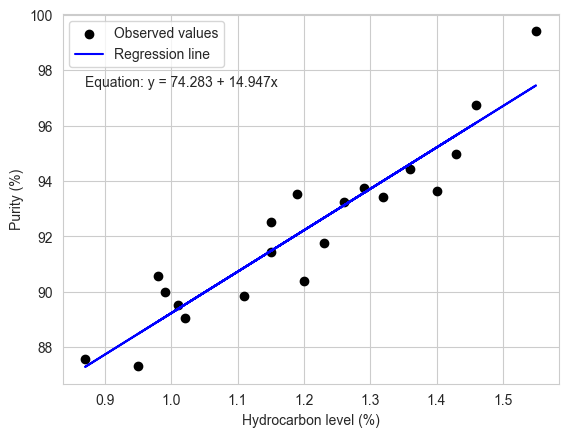

In [9]:
# create a scatterplot of the observed values
plt.scatter(xData, yData, color = 'black', label='Observed values')
# add a lineplot of the predicted values
#sns.lineplot(x = x, y = pred, color='red', marker='o', markers=True, label='Predicted values')
plt.plot(xData, y_pred, color='blue', label='Regression line')
# set labels and title
plt.xlabel('Hydrocarbon level (%)')
plt.ylabel('Purity (%)')

plt.text(np.min(xData), np.max(yData) - 2, f"Equation: y = {intercept_:.3f} + {slope_:.3f}x")
        
plt.legend()
plt.show()

## Test significance of the coefficients

In [10]:
# calculate residual/error 
residual_ = yData - y_pred
# residual sum of squares (RSS)
SSE = np.sum(residual_ ** 2)
# the variance of the error term
sigma_squared = np.sum(residual_**2) / (len(yData)-2)
# total sum of squares (TSS)
SST = np.sum((yData - y_mean) ** 2)

#print(f"Residual: {residual_}")
print(f"Variance: {sigma_squared}")
print(f"Residual sum of squares (SSE): {SSE:.3f}")
print(f"Total sum of squares (SST): {SST:.3f}")

# standard error (se)
se_b1 = np.sqrt(sigma_squared/denomerator)
print(f"se(b1): {se_b1}")
se_b0 = np.sqrt(sigma_squared*((1/len(yData)+((x_mean**2)/denomerator))))
print(f"se(b0): {se_b0}")

t_stats_b1 = slope_/se_b1
print(f"t-stats for b1: {t_stats_b1}")

t_stats_b0 = intercept_/se_b0
print(f"t-stats for b0: {t_stats_b0}")

df = len(yData) - 2
p_value_lower_b1 = stats.t.cdf(-np.abs(t_stats_b1), df)
p_value_upper_b1 = 1-stats.t.cdf(t_stats_b1, df)
p_value_b1 = p_value_upper_b1 + p_value_lower_b1
print(f"p_value_b1: {p_value_b1}")

p_value_lower_b0 = stats.t.cdf(-np.abs(t_stats_b0), df)
p_value_upper_b0 = 1-stats.t.cdf(t_stats_b0, df)
p_value_b0 = p_value_upper_b0 + p_value_lower_b0
print(f"p_value b0: {p_value_b0}")

Variance: 1.180545381956687
Residual sum of squares (SSE): 21.250
Total sum of squares (SST): 173.377
se(b1): 1.3167582697763436
se(b0): 1.5934733757852935
t-stats for b1: 11.35172649012508
t-stats for b0: 46.617229612503934
p_value_b1: 1.2273144083667505e-09
p_value b0: 1.5857378105688086e-20


In [11]:
mod = pg.linear_regression(xData, yData)
mod.round(4)

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,74.2833,1.5935,46.6172,0.0,0.8774,0.8706,70.9356,77.6311
1,x,14.9475,1.3168,11.3517,0.0,0.8774,0.8706,12.1811,17.7139


## An F-test (ANOVA)

In [12]:
def regression_f(predictor, outcome):
    # model the data, and store the model information in a variable called "mod"
    mod = pg.linear_regression(predictor, outcome)

    # call the outcome data "Y", just for the sake of generalizability
    Y = outcome

    # get the model residuals from the model object
    res = mod.residuals_

    # calculate the residual, the model, and the total sums of squares
    SS_res = np.sum(np.square(res))
    SS_tot = sum( (Y - np.mean(Y))**2 )
    SS_mod = SS_tot - SS_res

    # get the degrees of freedom for the model and the residuals
    df_mod = mod.df_model_
    df_res = mod.df_resid_

    # caluculate the mean squares for the model and the residuals
    MS_mod = SS_mod / df_mod
    MS_res = SS_res / df_res

    # calculate the F-statistic
    F = MS_mod / MS_res

    # estimate the p-value
    p = stats.f.sf(F, df_mod, df_res)

    # display the results
    print("F=",F, "p=", p)

In [13]:
regression_f(xData, yData)

F= 128.86169430660775 p= 1.22731434445939e-09


## Model Evaluation

In [14]:
num_col_xData = 1
r2score_ = (1 - (SSE / SST))
adj_r2 = 1 - ((SSE/SST)*(((len(yData)-1))/(len(yData)-num_col_xData-1)))
mae_ = np.mean(np.abs(yData - y_pred))
mse_ = np.average((yData - y_pred) ** 2, axis=0)
rmse_ = np.square(mse_)
sep_ = np.std(y_pred - yData)
rpd_ = np.std(yData)/sep_
bias_ = np.mean(y_pred - yData)

print(f"Coefficient of determination (R^2): {r2score_:.4f}")
print(f"Adjusted R^2: {adj_r2:.4f}")
print(f"Mean absolute error (MAE): {mae_:.4f}")
print(f"Mean squared error (MSE): {mse_:.4f}")
print(f"Root mean squared error (RMSE): {rmse_:.4f}")
print(f"Standard error prediction: {sep_:.4f}")
print(f"RPD: {rpd_:.4f}")
print(f"Bias: {bias_:.4f}")


Coefficient of determination (R^2): 0.8774
Adjusted R^2: 0.8706
Mean absolute error (MAE): 0.8434
Mean squared error (MSE): 1.0625
Root mean squared error (RMSE): 1.1289
Standard error prediction: 1.0308
RPD: 2.8564
Bias: 0.0000
